# Biomolecular simulation with GROMACS

In this tutorial, we will go over the very basics of standard biomolecular simulation. For that, we will use [GROMACS](https://www.gromacs.org/), one of the most widely used MD engines when it comes to biomolecules. GROMACS is a highly optimised package, with literal decades of development and the first choice for thousands of researchers around the world. This tutorial will NOT be an exhaustive look into everything one can do with GROMACS, since the ecosystem is huge and can take years to master completely. Instead, we will familiarise ourselves with its basic command line interface and, hopefully, in the end we will be able to comfortably set up simple systems and run unrestrained MD simulations.

## Part 1 - Preparing a protein simulation

In the first part of the tutorial we will learn how to prepare a small protein-in-water system and get it ready for a production simulation. We will start from a PDB file containing only the protein and end up with some GROMACS run-input files ready to use.

> **Note**
>
> If your machine cannot run some of the steps, precomputed intermediate structures, the ionised topology, and minimisation, NVT and NPT outputs are already in `exercise-1/`, at the paths used below. The `.xvg` files are also provided for the plots, so you can use those even if you cannot run `gmx energy`. If you cannot run `genion`, use `2RVD_ions.pdb` **together with** `2RVD_topol.top`; this topology already contains the ions, so do NOT use it for the earlier, un-ionised structure. Backup minimisation coordinates and energies are under [`exercise-1/results/`](exercise-1/results/).

### 1.1 - Familiarising ourselves with the system

The very first thing we should really do is visualize the system that we want to simulate. 

The following display is interactive, play with it for a while. What kind of molecule are we dealing with? What can you tell me about it? Why does it "move" if it is only one PDB file?

In [1]:
import MDAnalysis as mda
import nglview as nv

u_2RVD = mda.Universe("structures/2RVD.pdb")
nv.show_mdanalysis(u_2RVD)

/lmb/home/alexandrebg/.local/share/mamba/envs/gromacs-tutorial/lib/python3.12/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


NGLWidget(max_frame=19)

It is probably a good idea we inspect the [PDB file](structures/2RVD.pdb). Open it in another tab. At some point you will see these two lines:

```text
KEYWDS    BETA-HAIRPIN, MINI-PROTEIN, CHIGNOLIN, DE NOVO PROTEIN                
EXPDTA    SOLUTION NMR
```

Here we actually have some answers to the previous questions! We are dealing with a *de novo* designed protein, a beta-hairpin, studied through solution NMR. A bit further down we will read:

```text
REMARK 210 BEST REPRESENTATIVE CONFORMER IN THIS ENSEMBLE : 1
```

So this is a conformational ensemble! That explains why the molecule "moves" in the visualiser, every frame corresponds to one conformation. We are also told that the most representative conformer is the first one. Probably, then, it is a good idea if we save it.

In [2]:
u_2RVD.trajectory[0] # Conformers are stored as if they were a trajectory
u_2RVD.atoms.write("exercise-1/2RVD_conf1.pdb")

u_conf1 = mda.Universe("exercise-1/2RVD_conf1.pdb")
nv.show_mdanalysis(u_conf1)


/lmb/home/alexandrebg/.local/share/mamba/envs/gromacs-tutorial/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:885: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn(
/lmb/home/alexandrebg/.local/share/mamba/envs/gromacs-tutorial/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(
/lmb/home/alexandrebg/.local/share/mamba/envs/gromacs-tutorial/lib/python3.12/site-packages/MDAnalysis/coordinates/PDB.py:479: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn(


NGLWidget()

Now we can see that there is no play button on the visualizer, and we have just one structure. This will be our starting point and we are now ready to really start thinking about setting up the simulation.

### 1.2 - Preparation of the structure

Let's think now about the environment around this protein. Is it in vacuum? Does the PDB tell us anything about a simulation box? Luckily, the file gives us a clue. If we keep reading the PDB file we will bump into these lines:

```text
REMARK 215 THE COORDINATES IN THIS ENTRY WERE GENERATED FROM SOLUTION           
REMARK 215 NMR DATA.  PROTEIN DATA BANK CONVENTIONS REQUIRE THAT                
REMARK 215 CRYST1 AND SCALE RECORDS BE INCLUDED, BUT THE VALUES ON              
REMARK 215 THESE RECORDS ARE MEANINGLESS.  
```

This means the unit-cell information in this NMR structure is just a placeholder: it tells us nothing about the solution surrounding the protein. It does NOT mean the experimental protein was in vacuum, though. However, to simulate it in solution, we must define a box and add solvent.

Let's start with putting our protein in a finite box. This will be the first GROMACS command we will run. Open a terminal in the directory containing this notebook, and type the following:

```bash
gmx editconf -f exercise-1/2RVD_conf1.pdb -o exercise-1/2RVD_box.pdb -box 5 5 5
```

`editconf` means edit conformation, and is a command that allows simple manipulations of structure files, like translations, rotations and, in this case, adding a simulation box. We use `-f` to indicate the input file, `-o` for an output file and `-box` to give the size of the box in nanometres. Here, the box is a cubic box, so the angles between the box vectors will be 90 degrees. `editconf` can take many more options, you can inspect all you can do with it if you run `gmx editconf -h`; and this is true for all available GROMACS commands.

We can now visualise the result of the previous operation.

In [3]:
u_box = mda.Universe("exercise-1/2RVD_box.pdb")

view = nv.show_mdanalysis(u_box)
view.add_cartoon(selection="protein")
view.add_ball_and_stick(selection="protein")
view.add_unitcell()
view.center()
view

NGLWidget()

We now see a box around our protein! We have defined a 5 nm periodic box around the protein, rather than walls that will trap it. We will see in a bit what that means. 

However, our protein still looks quite lonely in the middle of that box. In nature, proteins usually do not appear in vacuum, unless something goes really, *really* wrong. We must therefore fix this and **solvate** the protein. The solvent of choice will be, of course, water; since that is the solvent of life. We can use GROMACS for that, in the same terminal you opened before, run:

```bash
gmx solvate -cp exercise-1/2RVD_box.pdb -o exercise-1/2RVD_solv.pdb
```

In this case `solvate` is pretty much self-explanatory. `-cp` provides the coordinates of the thing to be solvated. This does NOT have to be a protein. Again, with `-o` we decide the output file.

We can visualise the result of this:

In [4]:
u_solv = mda.Universe("exercise-1/2RVD_solv.pdb")

view = nv.show_mdanalysis(u_solv)
view.clear_representations()
view.add_cartoon(selection="protein")
view.add_ball_and_stick(selection="SOL")
view.add_unitcell()
view

/lmb/home/alexandrebg/.local/share/mamba/envs/gromacs-tutorial/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:372: UserWarning: Unknown element  found for some atoms. These have been given an empty element record. If needed they can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn(wmsg)


NGLWidget()

Now, that looks much better! We have quite a few waters accompanying our protein now. However, you may notice something that could seem strange at first: why are some water molecules **outside** the simulation box?

The answer lies in Periodic Boundary Conditions (PBC). Think about pac-man: he comes out one side of the map and immediately appears again through the opposite side. The box is a repeating unit cell, not a container with walls; molecules can cross its boundaries and interact with periodic images. Some coordinates may look outside the drawn box because of how the molecules are wrapped for display. The box will stay fixed in our NVT run, but can change when we later turn on a barostat in NPT. Again, more on this later.

With this, we have now a much more decent system and we can move to the next part of the tutorial.

### 1.3 - Parameter assignment

So far, we have just sort of manually placed molecules and atoms in a simulation box, but we have not run any simulation yet; no energies, no forces, no dynamics, no movement whatsoever. We must raise the question, however, of how will we inform our simulation engine about how to actually simulate our system. First and foremost, thus, we must decide our force field. 

*Force field* is just a fancy term for the equations **and parameters** used to describe our system. Think, for example, how can we describe a bond between two particles, maybe with a harmonic potential? What about electrostatic interactions, surely we would use the Coulomb potential? And dispersion-repulsion forces, maybe the Lennard-Jones or something else? Those choices, together with their fitted parameters, constitute the force field. Force fields come in several families which depend on the specific equations used to describe the system, their spatial resolution, etc. 

For this case, we will stick to a classical, atomistic force field; we will use a set of equations (this is, a functional form) that assigns one interacting particle per atom in the system, thus atomistic; and using a parameterised classical approximation rather than explicitly treating quantum mechanics. The advantage of these types of force fields is that they are relatively cheap to compute, at the loss of some accuracy in the treatment of the interactions. Despite this, they are widely used in biomolecular simulation.

We can use GROMACS to easily assign force field parameters to a structure file. In your terminal, execute the following:

```bash
gmx pdb2gmx -f exercise-1/2RVD_solv.pdb -o exercise-1/2RVD_amber.pdb -p exercise-1/2RVD_topol.top -i exercise-1/2RVD_posre.itp -ignh
```

In this command `pdb2gmx` takes us from a PDB file to GROMACS-usable inputs. It will create almost all that is necessary for us to run our subsequent simulations. With `-p` we will select the file to which GROMACS will write the *topology* of the system, basically a file that contains all the necessary definitions for the engine to understand *what* we are simulating and *how* we are doing it. With `-i` we indicate where to write the optional position-restraint definitions. `-ignh` stands for Ignore Hydrogens: GROMACS will discard input hydrogen positions and rebuild them according to the selected force field; useful when the input hydrogen names do not match its conventions.

You will be prompted first to select which force field do you want to use. GROMACS can automatically assign parameters using several force fields. For our case, we will use AMBER99SB-ILDN, so select its entry from the menu and press enter (it was `8` when this tutorial was written). Immediately after this, we will be asked about what water model to use. TIP3P will suffice for us, so select its entry and press enter again (it was `1` when this tutorial was written). 

Let us now pay attention to some extra bits of information that GROMACS gives us when we run this. GROMACS commands tend to be quite verbose and provide lots of info, it is recommended to read them carefully the very first times we are running them to understand what we are doing. It will mention how it is opening force field file definitions, analyse the PDB file, split residues, assign parameters for bonds, angles, torsions, etc. Nearly at the end we will encounter: 

```text
Total mass in system 73356.314 a.m.u.

Total charge in system -2.000 e
```

What do you think of these numbers? Do they seem reasonable to you? Should we do something about this? We will come back to this in a bit.

For now, let's open and read the generated topology file, [`exercise-1/2RVD_topol.top`](exercise-1/2RVD_topol.top). The copy in the repository has already been updated with ions by a later step, so its final molecule counts will differ from what you see right now. The file starts with several comments on how it was generated (note how comments are indicated with `;` characters). It then proceeds to `#include` the master force field file, where the main definitions are located, think of, for example, what are the van der Waals parameters for each atom type. It then proceeds to define several sections, like `[ atoms ]` or `[ bonds ]` or `[ angles ]`. GROMACS is, admittedly, a bit cryptic with these definitions and can be difficult to understand for someone who just got started. The only thing you need to know now is that, in general, they define for which atoms (by their index) a given interaction happens, which functional form is used to describe such interaction (usually under the column `funct`) and some extra data. At the end of the file we have a `[ molecules ]` section that tells us how many of each molecule types we have in the system, appearing in the same order that they appear in the PDB files. For a more detailed explanation you can consult the [GROMACS documentation](https://manual.gromacs.org/documentation/current/reference-manual/topologies/topology-file-formats.html).

### 1.4 - Energy minimisation

We now have the structure and a topology describing its interactions, but we still need to prepare it before running dynamics. What we do not have, however, is any guarantee that our starting structure is anywhere close to a conformation that is free of severe atomic overlaps. Most probably, if we tried to run dynamics in our current structure we would run into numerical issues. Therefore, we must first "relax" the starting conformation given the force field. This is not dynamics, it is just a minimisation algorithm that will lower the potential energy towards a local minimum of the chosen force field.

So, how do we use GROMACS for this? First and foremost, we need to generate a GROMACS run-input file, which our MD engine can read and work on. Before going into the command, let's take a look at the [minimisation instruction file](mdp/minim.mdp). Files ending with the `.mdp` extension are where we write the instructions for GROMACS to carry on its job. We will indicate things like what integrator to use, what kind of electrostatic treatment to use, how often to write results to file, etc. You can find a detailed explanation of every available option, of course, in the [GROMACS docs](https://manual.gromacs.org/current/user-guide/mdp-options.html). For now, we will focus on:

```text
integrator      = steep
emtol           = 10.0       ; kJ mol^-1 nm^-1
nsteps          = 10000
```

That is informing GROMACS that this is an energy minimisation (no dynamics!), using the steepest descent algorithm, until a maximum force tolerance of 10 $kJ\ mol^{-1}\ nm^{-1}$ is achieved or at most 10000 minimisation steps have been computed. Reaching the step limit does NOT guarantee that the force tolerance was met. We can now prepare the GROMACS run-input file with the following command:

```bash
gmx grompp -f mdp/minim.mdp -c exercise-1/2RVD_amber.pdb -p exercise-1/2RVD_topol.top -o exercise-1/2RVD_minim.tpr
```

Wait a second, **FATAL ERROR**?? What have we done wrong?? Let's carefully read the output:

```text
WARNING 1 [file 2RVD_topol.top, line 1657]:
  You are using Ewald electrostatics in a system with net charge. This can
  lead to severe artifacts, such as ions moving into regions with low
  dielectric, due to the uniform background charge. We suggest to
  neutralize your system with counter ions, possibly in combination with a
  physiological salt concentration.
```

and then

```text
Fatal error:
Too many warnings (1).
If you are sure all warnings are harmless, use the -maxwarn option.
```

Aha! Our system has net charge! Indeed, this can be problematic when using [the Ewald formalism](https://doi.org/10.1063/1.470117) to treat the electrostatic interactions. So what should we do about this? We need to include counterions but how? Surely GROMACS provides some tools *that are no convoluted at all, right?*. Well...

```bash
gmx grompp -f mdp/minim.mdp -c exercise-1/2RVD_amber.pdb -p exercise-1/2RVD_topol.top -o exercise-1/2RVD_minim.tpr -maxwarn 1
```

Run the previous command. `grompp` stands for **GROM**ACS **P**re **P**rocessor and is one of its most important tools, used to generate the run-input files. The flags `-f`, `-c` and `-p` indicate the input instructions, conformation and topology, respectively, and with `-o` we indicate the output run-input file, which uses the `.tpr` extension. To this we will append the `-maxwarn 1` flag, allowing this warning **only** to make a temporary input for the next step. Do NOT run dynamics from this charged-system `.tpr`: after adding ions we will regenerate it without `-maxwarn`. Now, we can run the following command:

```bash
gmx genion -s exercise-1/2RVD_minim.tpr -o exercise-1/2RVD_ions.pdb -p exercise-1/2RVD_topol.top -neutral -conc 0.15 -pname K -nname CL
```

You will be prompted to select what is the solvent group, and molecules from that group will be replaced by ions. Select the `SOL` group (it was `13` when this tutorial was written); GROMACS will replace some water molecules with ions.

`genion` stands for, you guessed it, **gen**erate **ion**s. It NEEDS a `.tpr` file to work, passed with the `-s` flag, so that is why we tricked GROMACS with the previous `grompp` command. We also need to pass what is the topology file, since we need to update the water molecules that were replaced by ions. The rest of the flags indicate what ions to add, and how much, basically saying to ensure that the system is `-neutral`, and on top of that adding K and CL to target approximately 0.15 M salt. Because only whole ions can be added, the actual concentration in this small box is approximate.

In [5]:
u_ions = mda.Universe("exercise-1/2RVD_ions.pdb")

view = nv.show_mdanalysis(u_ions)
view.clear_representations()
view.add_cartoon(selection="protein")
view.add_ball_and_stick(selection="SOL")
view.add_spacefill(selection="[K,CL]")
view.add_unitcell()
view

NGLWidget()

In the previous widget we can see that we now have several spheres representing the ions. Now, we can generate our minimisation binaries again, run:

```bash
gmx grompp -f mdp/minim.mdp -c exercise-1/2RVD_ions.pdb -p exercise-1/2RVD_topol.top -o exercise-1/2RVD_minim.tpr
```

This should now complete without the net-charge warning! We are ready to run the minimisation step:

```bash
gmx mdrun -v -deffnm exercise-1/2RVD_minim
```

> **Note**
>
> If running this is very slow on your machine, do not worry! Precomputed minimisation results are under `exercise-1/results/`. The precomputed `2RVD_minim.gro`, `2RVD_minim.edr` and `2RVD_energy.xvg` are already in `exercise-1/`, as are the NVT and NPT results. Backup minimisation coordinates and energies are under `exercise-1/results/`, in case you need to restore them.

`mdrun` is the tool that we will be using any time we need to *run* any simulation. The `-v` flag is there to make the output verbose, and the `-deffnm` flag is a way of indicating GROMACS that it should use the necessary files starting with that string, and any file that is produced should also start with that string. Once the minimisation has finished we can take a look at the resulting minimised structure.


In [6]:
u_minim = mda.Universe("exercise-1/2RVD_minim.gro")

view = nv.show_mdanalysis(u_minim)
view.clear_representations()
view.add_cartoon(selection="protein")
view.add_ball_and_stick(selection="SOL")
view.add_spacefill(selection="[K,CL]")
view.add_unitcell()
view

NGLWidget()

While the minimisation was running we could see that the potential energy of the system was being printed to the terminal. We can access all that information once the minimisation has completed. One of the outputs of this step was `exercise-1/2RVD_minim.edr`. `.edr` files contain a log of energies and energy-related quantities that are computed during simulation. These are binary files, however, and have to be postprocessed to get them into a more human-readable form:

```bash
gmx energy -f exercise-1/2RVD_minim.edr -o exercise-1/2RVD_energy.xvg
```

With this command, we will be prompted to select a quantity to output to a postprocessed file, often in the `xvg` format. We are interested in the potential energy in this case, so select `Potential` from the menu (it was `11` when this tutorial was written) and then finish the selection. We can inspect [the result](exercise-1/2RVD_energy.xvg), focus on:

```text
@    title "GROMACS Energies"
@    xaxis  label "Time (ps)"
@    yaxis  label "(kJ/mol)"
@TYPE xy
```

This is telling us that the file contains two columns: an x-coordinate labelled "Time (ps)" by GROMACS and the potential energy in kJ/mol. Here the x-values correspond to minimisation steps, NOT elapsed simulation time. If we read further down the file we can see that the data is stored in two columns. We can now use a small python snippet to plot the result:

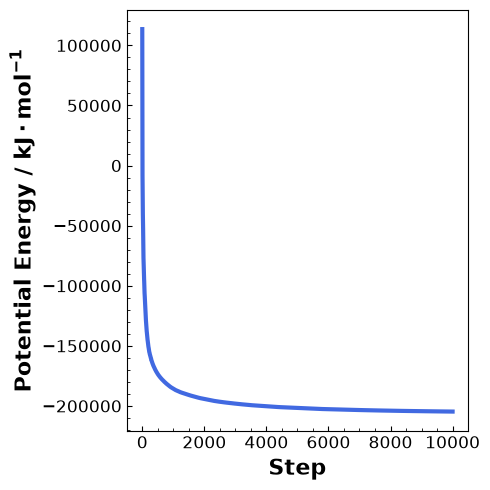

In [7]:
import numpy as np
import matplotlib.pyplot as plt

minim_log = np.loadtxt(
    "exercise-1/2RVD_energy.xvg", 
    comments = ("#", "@") # Ignore all lines that start with any of these characters
)

fig, ax = plt.subplots(
    figsize = (5,5),
    layout = "tight"
)

ax.plot(
    minim_log[:,0], minim_log[:,1], # First column is minimisation step; second column is potential energy
    lw = 3, color = "royalblue"
)

ax.set_xlabel("Step", fontsize = 16, fontweight = "bold")
ax.set_ylabel(r"Potential Energy / $\mathbf{kJ \cdot mol^{-1}}$", fontsize = 16, fontweight = "bold")

ax.minorticks_on()

ax.tick_params(labelsize = 12, which = "both", direction = "in")

What can you tell me about this graph? Interpret it.

### 1.5 - Equilibration

We have lowered the potential energy and relieved some unfavourable contacts. A negative energy does NOT mean the conformation is thermodynamically stable: the zero of potential energy is arbitrary, and minimisation does not establish equilibrium. Check the minimisation log: the supplied run stopped at the step limit, with the maximum force still above the requested tolerance. That does not prevent us from continuing this exercise, but we should not call it converged. To obtain a conformational *ensemble* we need to run dynamics. In any case, we usually cannot jump immediately to *production* dynamics. Biomolecular systems have many degrees of freedom and slow modes that take time to approach equilibrium. Therefore, most of the times after running an energy minimisation, we will run some equilibration steps.

We will start with NVT equilibration: a fixed number of particles (N), a fixed volume (V) and a thermostat targeting a temperature (T). The instantaneous temperature can still fluctuate. We will start by first taking a look at the [`.mdp` file](mdp/eq_nvt.mdp).

```text
; Run control
integrator              = md        ; Leap-frog integrator
dt                      = 0.002     ; ps = 2 fs
nsteps                  = 500000    ; 500000 * 0.002 ps = 1000 ps = 1 ns

; Output control
nstlog                  = 1000 ; Every 2 ps
nstenergy               = 1000 ; Every 2 ps
nstxout-compressed      = 5000 ; Every 10 ps

[...]

; Temperature coupling
tcoupl                  = V-rescale
tc-grps                 = Protein Water_and_Ions
tau-t                   = 1.0 1.0
ref-t                   = 340 340

; Initial velocities
gen-vel                 = yes
gen-temp                = 340
gen-seed                = -1


; Pressure coupling
pcoupl                  = no
```

Here we have set `integrator = md` and therefore we are requesting actual dynamics using the [Leapfrog integrator](https://en.wikipedia.org/wiki/Leapfrog_integration). We request a timestep of 2 femtoseconds, relatively conservative since this is the first equilibration step; and we run it for 500000 steps for a total of 1 ns simulated time. The next section refers to how often we will write to file the results of the simulation. The first two items tell about the `.log` and the `.edr` file, respectively; and the last item relates to the frequency with which we will write an `.xtc` trajectory file. The `compressed` part refers to the compressed coordinate trajectory (usually `.xtc`), which does NOT store velocities or forces, unlike a full-precision `.trr` trajectory.

Now, what about temperature? We have selected `tcoupl = V-rescale`, a thermostat that adjusts the kinetic energy, with a stochastic component, to sample the desired temperature distribution. With `tc-grps = Protein Water_and_Ions` we couple the protein and the water-plus-ions group separately. The two values of `ref-t` set both target temperatures to 340 K, while the two values of `tau-t` give each group a coupling time of 1 ps. This does NOT mean that either group's temperature will be exactly 340 K at every step; it will fluctuate. Since minimisation did not give us a set of thermal velocities, `gen-vel = yes` asks GROMACS to draw them at `gen-temp = 340` K. The `gen-seed = -1` option selects a random seed automatically, so different runs need not start with identical velocities.

Finally, `pcoupl = no` means that we are not coupling the pressure to a target value: the box volume stays fixed during this NVT run. We can still *measure* the pressure, but it will fluctuate and may not be close to 1 bar. Later we will let the box adjust during NPT equilibration.

Next we can generate the appropriate run-input file

```bash
gmx grompp -f mdp/eq_nvt.mdp -c exercise-1/2RVD_minim.gro -p exercise-1/2RVD_topol.top -o exercise-1/2RVD_nvt.tpr
```

You should see the following line

```text
Velocities were taken from a Maxwell distribution at 340 K
```

Why do you think that is? Does this match the target temperature? Then, run the simulation

```bash
gmx mdrun -v -deffnm exercise-1/2RVD_nvt
```

We can visualise the simulation result as follows:

In [8]:
import MDAnalysis.transformations as trans

u_nvt = mda.Universe(
    "exercise-1/2RVD_minim.gro",
    "exercise-1/2RVD_nvt.xtc",
    to_guess = ["bonds", "masses"]
)

protein = u_nvt.select_atoms("protein")
solvent = u_nvt.select_atoms("not protein")

u_nvt.trajectory.add_transformations(
    trans.unwrap(protein),
    trans.center_in_box(protein, center="mass"),
    trans.wrap(solvent, compound="residues"),
)

view = nv.show_mdanalysis(u_nvt)
view.clear_representations()

view.add_cartoon(selection="protein")
view.add_ball_and_stick(selection="protein")
view.add_unitcell()

view

NGLWidget(max_frame=100)

But, of course, we will need to monitor some more things to see how our equilibration is going. We can postprocess again the `.edr` file and obtain the relevant quantities from it.

```bash
gmx energy -f exercise-1/2RVD_nvt.edr -o exercise-1/2RVD_nvt.xvg
```

When prompted, select Total Energy, Temperature and Pressure. Then, we can plot the results:

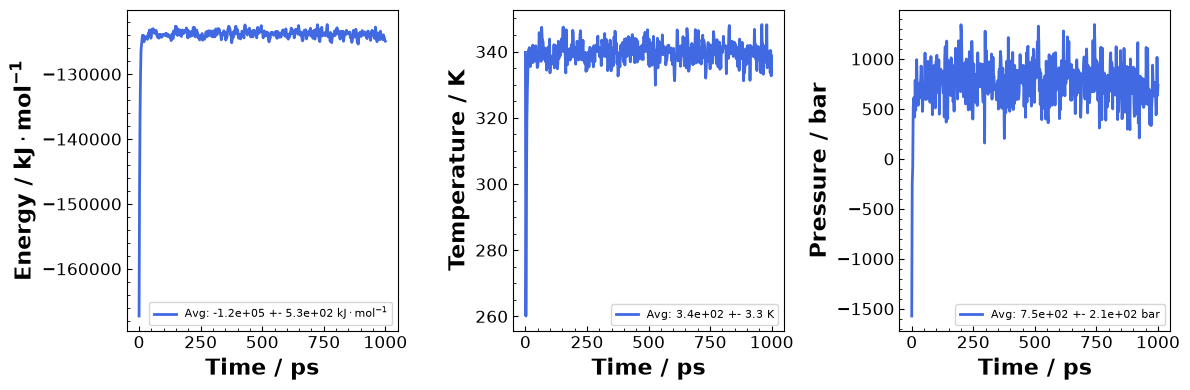

In [9]:
nvt_edr = np.loadtxt(
    "exercise-1/2RVD_nvt.xvg",
    comments = ("#", "@")
)

time        = nvt_edr[:,0]
energy      = nvt_edr[:,1]
temperature = nvt_edr[:,2]
pressure    = nvt_edr[:,3]

fig, ax = plt.subplots(
    1, 3,
    figsize = (12, 4),
    layout = "tight"
)

ax[0].plot(
    time, energy,
    color = "royalblue", lw = 2,
    label = rf"Avg: {np.mean(energy[-250:]):.2g} +- {np.std(energy[-250:], ddof = 1):.2g} $\mathrm{{kJ \cdot mol^{{-1}}}}$"
)
ax[1].plot(
    time, temperature,
    color = "royalblue", lw = 2,
    label = f"Avg: {np.mean(temperature[-250:]):.2g} +- {np.std(temperature[-250:], ddof = 1):.2g} K"
)
ax[2].plot(
    time, pressure,
    color = "royalblue", lw = 2,
    label = f"Avg: {np.mean(pressure[-250:]):.2g} +- {np.std(pressure[-250:], ddof = 1):.2g} bar"
)

ax[0].set_ylabel(
    r"Energy / $\mathbf{kJ} \cdot \mathbf{mol^{-1}}$",
    fontsize = 16, fontweight = "bold"
)
ax[1].set_ylabel(
    r"Temperature / K",
    fontsize = 16, fontweight = "bold"
)
ax[2].set_ylabel(
    r"Pressure / bar",
    fontsize = 16, fontweight = "bold"
)

for ax_i in ax:
    ax_i.minorticks_on()
    ax_i.tick_params(
        which = "both",
        direction = "in",
        labelsize = 12
    )

    ax_i.set_xlabel(
        "Time / ps",
        fontsize = 16, fontweight = "bold"
    )

    ax_i.legend(fontsize = 8)

Discuss these results for a bit. Why does the total energy of the system increase? Is the thermostat working? Why is the pressure so high? The plotted averages and standard deviations use the last 250 points: they describe fluctuations, NOT the uncertainty of the mean (successive points are correlated).

Pressure is not controlled in NVT and fluctuates substantially even at equilibrium. To let the volume (and hence density) relax towards a target pressure, our next step is an NPT simulation. The barostat controls the pressure statistically, NOT at every instant. Let's take a look at the [relevant `.mdp` file](mdp/eq_npt.mdp)

```text
; Run control
integrator              = md        ; Leap-frog integrator
dt                      = 0.002     ; ps = 2 fs
nsteps                  = 500000    ; 500000 * 0.002 ps = 1000 ps = 1 ns

; Output control
nstlog                  = 1000
nstenergy               = 1000
nstxout-compressed      = 5000

[...]

; Temperature coupling
tcoupl                  = V-rescale
tc-grps                 = Protein Water_and_Ions
tau-t                   = 1.0 1.0
ref-t                   = 340 340

; Initial velocities
gen-vel                 = no

; Pressure coupling
pcoupl                  = C-rescale
pcoupltype              = isotropic
ref-p                   = 1.0
tau-p                   = 5.0
compressibility         = 4.5e-5
```

The important new setting is `pcoupl = C-rescale`, which selects the [stochastic cell-rescaling barostat](https://doi.org/10.1063/5.0020514). With `gen-vel = no`, we keep the velocities saved in the NVT `.gro` file rather than drawing new ones.

At this point, we should be quite familiar with what we need to do to prepare the binaries and run a simulation! Run, in a terminal:

```bash
gmx grompp -f mdp/eq_npt.mdp -c exercise-1/2RVD_nvt.gro -p exercise-1/2RVD_topol.top -o exercise-1/2RVD_npt.tpr

gmx mdrun -v -deffnm exercise-1/2RVD_npt
```

We can again extract the same quantities (Total Energy, Temperature and Pressure, in that order) to an `.xvg` file

```bash
gmx energy -f exercise-1/2RVD_npt.edr -o exercise-1/2RVD_npt.xvg
```

and plot it:

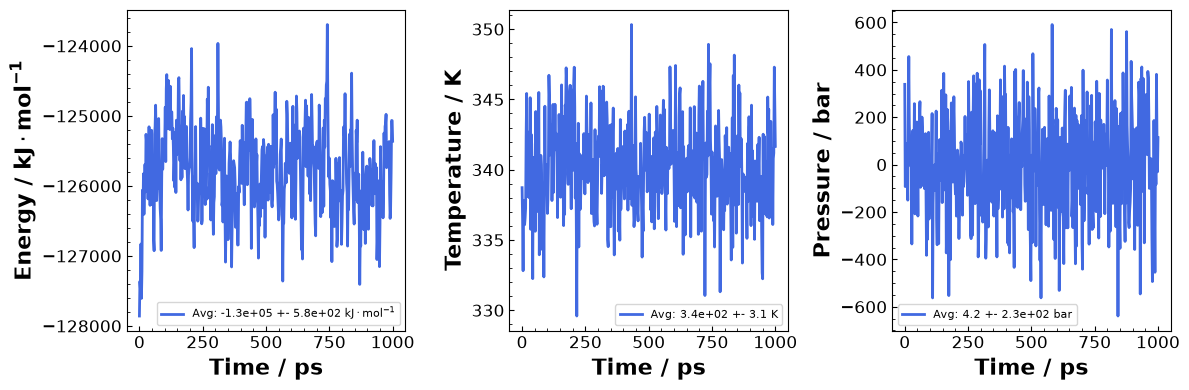

In [10]:
npt_edr = np.loadtxt(
    "exercise-1/2RVD_npt.xvg",
    comments = ("#", "@")
)

time        = npt_edr[:,0]
energy      = npt_edr[:,1]
temperature = npt_edr[:,2]
pressure    = npt_edr[:,3]

fig, ax = plt.subplots(
    1, 3,
    figsize = (12, 4),
    layout = "tight"
)

ax[0].plot(
    time, energy,
    color = "royalblue", lw = 2,
    label = rf"Avg: {np.mean(energy[-250:]):.2g} +- {np.std(energy[-250:], ddof = 1):.2g} $\mathrm{{kJ \cdot mol^{{-1}}}}$"
)
ax[1].plot(
    time, temperature,
    color = "royalblue", lw = 2,
    label = f"Avg: {np.mean(temperature[-250:]):.2g} +- {np.std(temperature[-250:], ddof = 1):.2g} K"
)
ax[2].plot(
    time, pressure,
    color = "royalblue", lw = 2,
    label = f"Avg: {np.mean(pressure[-250:]):.2g} +- {np.std(pressure[-250:], ddof = 1):.2g} bar"
)

ax[0].set_ylabel(
    r"Energy / $\mathbf{kJ} \cdot \mathbf{mol^{-1}}$",
    fontsize = 16, fontweight = "bold"
)
ax[1].set_ylabel(
    r"Temperature / K",
    fontsize = 16, fontweight = "bold"
)
ax[2].set_ylabel(
    r"Pressure / bar",
    fontsize = 16, fontweight = "bold"
)

for ax_i in ax:
    ax_i.minorticks_on()
    ax_i.tick_params(
        which = "both",
        direction = "in",
        labelsize = 12
    )

    ax_i.set_xlabel(
        "Time / ps",
        fontsize = 16, fontweight = "bold"
    )

    ax_i.legend(fontsize = 8)

What can we tell from these plots? The total energy rises at the beginning of the NPT run, then fluctuates without an obvious sustained drift. The temperature keeps fluctuating around our target of 340 K, so the thermostat seems to be doing its job. The pressure looks a lot noisier: it can be hundreds of bar above or below the target at any one instant! But its average over the last half of the run is about 4 bar, much closer to our target of 1 bar than the roughly 750 bar we saw in NVT. This is what we expect from a barostat: it does NOT pin the instantaneous pressure to 1 bar. Are we ready to declare the system fully equilibrated? Not quite from these plots alone; we should also check whether the box volume or density has settled down, and whether these averages remain similar over a longer run.

## Part 2 - Do coupling schemes matter?

In the first part we used a thermostat to keep our protein in water near 340 K, and a barostat to allow its box to adjust to 1 bar. But are all thermostats and barostats interchangeable? Would you be satisfied if two simulations had the same *average* temperature and pressure? In this exercise we will try changing these choices, one at a time, and see what happens.

We will use the final NPT state from Part 1 as the starting point for **four separate simulations**. Two of them will compare thermostats with the volume held fixed (NVT); the other two will compare barostats while keeping the thermostat the same (NPT). All four start from the *same* [`2RVD_npt.cpt`](exercise-1/2RVD_npt.cpt), containing the coordinates and velocities, NOT from one another's final structures. Otherwise, how could we tell what caused any differences?

> **Note**
>
> These are 1 ns demonstrations, not long production simulations. I have provided the `.edr` and processed `.xvg` files in [`exercise-2/results/`](exercise-2/results/), plus the two NVT trajectories needed to recalculate the water MSD. The matching `.tpr` inputs are in `exercise-2/`. If the runs take too long on your machine, you can work through the analysis using these files directly. In the terminal, run the commands from the directory containing this notebook.

### 2.1 - What does the thermostat do to dynamics?

First, we will compare [V-rescale](mdp/ex2_nvt_vrescale.mdp) with [Andersen-massive](mdp/ex2_nvt_andersen.mdp). We could simply call one of them *good* and the other one *bad*, but that would miss the interesting part. Both can produce a sensible equilibrium temperature distribution. Andersen-massive, however, repeatedly assigns new velocities to all the atoms in the coupled group. What do you think that does to how far a water molecule travels?

Let's open the two `.mdp` files. They have the same timestep, cutoffs, force field settings, output frequency and starting velocities; here are the relevant bits:

```text
; Run control (both files)
integrator              = md-vv
dt                      = 0.002     ; ps = 2 fs
nsteps                  = 500000    ; 1 ns
continuation            = yes
gen-vel                 = no

; Output control (both files)
nstenergy               = 100       ; every 0.2 ps
nstxout-compressed      = 500       ; every 1 ps

; Temperature coupling: ex2_nvt_vrescale.mdp
tcoupl                  = V-rescale
tc-grps                 = System
tau-t                   = 0.1
ref-t                   = 340

; Temperature coupling: ex2_nvt_andersen.mdp
tcoupl                  = Andersen-massive
tc-grps                 = System
tau-t                   = 0.1
ref-t                   = 340

; Pressure coupling (both files)
pcoupl                  = no
```

Why `md-vv` this time, rather than the leap-frog `md` integrator from Part 1? GROMACS does not support Andersen coupling with `md`, so we use velocity Verlet in **both** runs to keep the comparison fair. We also use a single temperature group (`System`) for both. With the constraints on our hydrogen bonds, GROMACS requires the `Andersen-massive` variant rather than independent Andersen collisions. For it, `tau-t = 0.1` ps means a velocity redraw every 0.1 ps; for V-rescale `tau-t` is a coupling time, NOT the interval between collisions. This is an intentionally strong comparison, not a claim that the two thermostats have equal strength. Notice also `gen-vel = no`: we do NOT want to draw different starting velocities for each branch!

Run the following commands in a terminal. `-t` supplies the checkpoint from Part 1 to `grompp`. We use `-pin on` to keep the threads on their assigned cores; the runs below are **sequential**, so they will not compete for the same cores.

```bash
mkdir -p exercise-2/results
gmx grompp -f mdp/ex2_nvt_vrescale.mdp -c exercise-1/2RVD_npt.gro -t exercise-1/2RVD_npt.cpt -p exercise-1/2RVD_topol.top -o exercise-2/nvt_vrescale.tpr
gmx mdrun -s exercise-2/nvt_vrescale.tpr -deffnm exercise-2/results/nvt_vrescale -ntmpi 4 -ntomp 8 -pin on

gmx grompp -f mdp/ex2_nvt_andersen.mdp -c exercise-1/2RVD_npt.gro -t exercise-1/2RVD_npt.cpt -p exercise-1/2RVD_topol.top -o exercise-2/nvt_andersen.tpr
gmx mdrun -s exercise-2/nvt_andersen.tpr -deffnm exercise-2/results/nvt_andersen -ntmpi 4 -ntomp 8 -pin on
```

We will first look at their temperatures. As before, the `.edr` files are binary, so use `gmx energy` to extract the `Temperature` term from each one (select it by when prompted):

```bash
gmx energy -f exercise-2/results/nvt_vrescale.edr -o exercise-2/results/nvt_vrescale_temperature.xvg
gmx energy -f exercise-2/results/nvt_andersen.edr -o exercise-2/results/nvt_andersen_temperature.xvg
```

We can now compare the two traces, and the distribution of the temperatures they visit:

V-rescale: temperature = 340.0 ± 3.1 K (mean ± SD)
Andersen-massive: temperature = 340.1 ± 3.1 K (mean ± SD)


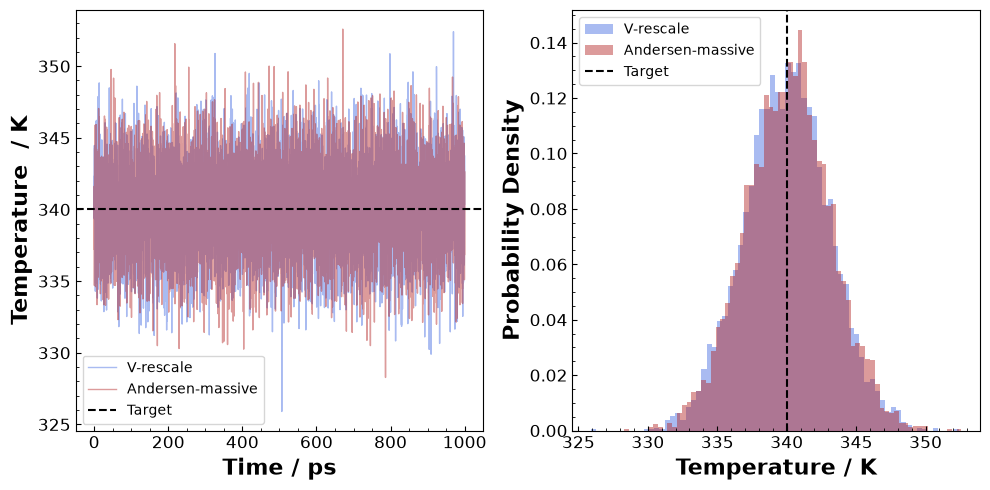

In [11]:
temp_vrescale = np.loadtxt('exercise-2/results/nvt_vrescale_temperature.xvg', comments=('#', '@'))
temp_andersen = np.loadtxt('exercise-2/results/nvt_andersen_temperature.xvg', comments=('#', '@'))

colors = {
    "V-rescale":"royalblue",
    "Andersen-massive":"firebrick"
}

fig, ax = plt.subplots(1, 2, figsize=(10, 5), layout='tight')
for name, data in [('V-rescale', temp_vrescale), ('Andersen-massive', temp_andersen)]:
    ax[0].plot(data[:, 0], data[:, 1], lw=1, label=name, color = colors[name], alpha = 0.45)
    ax[1].hist(data[:, 1], bins=int(np.sqrt(len(data))), density=True,
               alpha=0.45, label=name, color = colors[name])
    print(f'{name}: temperature = {data[:, 1].mean():.1f} ± {data[:, 1].std(ddof=1):.1f} K (mean ± SD)')

ax[0].axhline(340, color='black', ls='--', label='Target')
ax[1].axvline(340, color='black', ls='--', label='Target')

ax[0].set_xlabel(
    "Time / ps",
    fontsize = 16, fontweight = "bold"
)
ax[1].set_xlabel(
    "Temperature / K",
    fontsize = 16, fontweight = "bold"
)

ax[0].set_ylabel(
    "Temperature  / K",
    fontsize = 16, fontweight = "bold"
)
ax[1].set_ylabel(
    "Probability Density",
    fontsize = 16, fontweight = "bold"
)

for axis in ax:
    axis.minorticks_on()
    axis.tick_params(
        which = "both",
        direction = "in",
        labelsize = 12
    )
    axis.legend(fontsize = 10)

Huh, the temperatures do not look all that different! Both fluctuate near 340 K. If we stopped here, we might conclude that our thermostat choice did not matter. But temperature alone says nothing about *how* the molecules move. Let's ask GROMACS for the mean-squared displacement (MSD) of the water molecules: roughly speaking, how far they travel as the time interval increases. In a terminal, run:

```bash
gmx msd -f exercise-2/results/nvt_vrescale.xtc -s exercise-2/nvt_vrescale.tpr -o exercise-2/results/nvt_vrescale_msd.xvg
gmx msd -f exercise-2/results/nvt_andersen.xtc -s exercise-2/nvt_andersen.tpr -o exercise-2/results/nvt_andersen_msd.xvg
```

Select the `SOL` group for *each* command. GROMACS accounts for periodic crossings when computing the displacement. The first column of the `.xvg` is now a **lag time** (how far apart two snapshots are), rather than the simulation time. We can also use the Einstein relation for diffusion in three dimensions to get an estimate of the diffusion coefficient:

$$\mathrm{MSD}(\tau) = \langle |\mathbf{r}(t+\tau)-\mathbf{r}(t)|^2 \rangle \simeq 6D\tau.$$

So, if the MSD grows roughly linearly with lag time $\tau$, its slope is $6D$. Let's fit a straight line from 100 to 1000 ps, allowing an intercept rather than forcing the fit through zero, since the short-time motion need not yet be diffusive. This choice is illustrative, not a substitute for checking the fit window in longer runs. Let's plot both the MSD and our fitted lines:

V-rescale: D ≈ 0.0094 nm²/ps = 9.4e-05 cm²/s
Andersen-massive: D ≈ 0.0020 nm²/ps = 2e-05 cm²/s


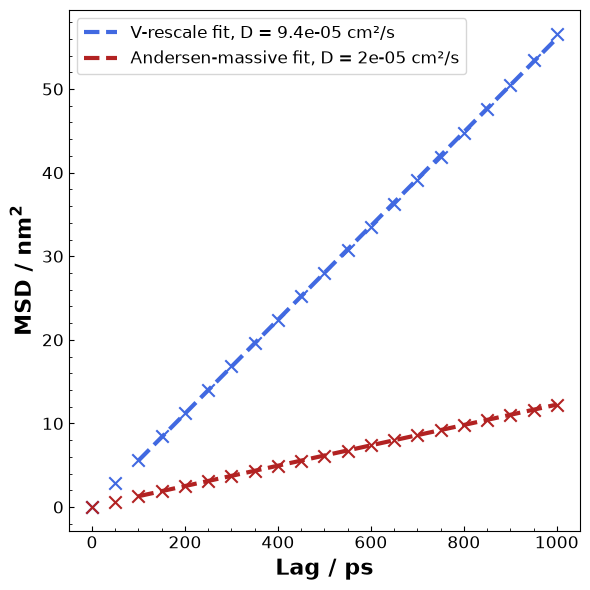

In [12]:
fig, ax = plt.subplots(figsize=(6, 6), layout='tight')
fit_start, fit_end = 100, 1000  # ps of lag time
for name, filename in [('V-rescale', 'nvt_vrescale'), ('Andersen-massive', 'nvt_andersen')]:
    msd = np.loadtxt(f'exercise-2/results/{filename}_msd.xvg', comments=('#', '@'))
    lag, displacement = msd[:, 0], msd[:, 1]
    in_fit = (lag >= fit_start) & (lag <= fit_end)
    slope, intercept = np.polyfit(lag[in_fit], displacement[in_fit], 1)
    diffusion = slope / 6  # nm^2/ps, for three-dimensional diffusion
    ax.scatter(lag[::50], displacement[::50], color = colors[name], s = 80, marker = "x")
    ax.plot(lag[in_fit], slope * lag[in_fit] + intercept, '--',
             label=f'{name} fit, D = {diffusion * 1e-2:.2g} cm²/s', color = colors[name], lw = 3)
    print(f'{name}: D ≈ {diffusion:.4f} nm²/ps = {diffusion * 1e-2:.2g} cm²/s')
ax.set_xlabel("Lag / ps", fontsize = 16, fontweight = "bold")
ax.set_ylabel(r"MSD / nm$\mathbf{^{2}}$", fontsize = 16, fontweight = "bold")
ax.minorticks_on()
ax.tick_params(
    which = "both",
    direction = "in",
    labelsize = 12
)
ax.legend(fontsize = 12)

What do you see? In the supplied runs, at a lag of 500 ps, the water MSD is about 28 $\mathrm{nm}^2$ with V-rescale, but only about 6.2 $\mathrm{nm}^2$ with Andersen-massive. Reassigning velocities so frequently has slowed the apparent motion of water, even though *both* simulations have about the same temperature! Andersen can still be useful if we care about equilibrium configurations rather than realistic time correlations; the problem is using this strongly coupled variant when we want to study physical dynamics. Our fit gives roughly $9.4 \times 10^{-5}$ $\mathrm{cm}^2/\mathrm{s}$ for V-rescale and $2.0 \times 10^{-5}$ $\mathrm{cm}^2/\mathrm{s}$ for Andersen-massive. We used $D = \mathrm{slope}/6$, with $1 \; \mathrm{nm}^2/\mathrm{ps} = 10^{-2} \; \mathrm{cm}^2/\mathrm{s}$. These are **estimates for these trajectories**, not precise diffusion coefficients: the MSD points are correlated, and we have only 1 ns of simulation. What would you want to change before reporting a reliable value?

### 2.2 - What does the barostat do to fluctuations?

Now let us turn to pressure coupling. Our starting box was already close to equilibrium after Part 1, so we will branch again from the **same** checkpoint and compare [C-rescale](mdp/ex2_npt_crescale.mdp) against [Berendsen](mdp/ex2_npt_berendsen.mdp). Again, we keep the thermostat, starting state and all the other settings the same. Take a look at the relevant part of the two `.mdp` files:

```text
; Both files
integrator              = md-vv
dt                      = 0.002
nsteps                  = 500000    ; 1 ns
continuation            = yes
gen-vel                 = no
tcoupl                  = V-rescale
tc-grps                 = System
tau-t                   = 0.1
ref-t                   = 340

; ex2_npt_crescale.mdp        ex2_npt_berendsen.mdp
pcoupl = C-rescale            pcoupl = Berendsen

; Both files
pcoupltype              = isotropic
ref-p                   = 1.0       ; bar
tau-p                   = 5.0       ; ps
compressibility         = 4.5e-5    ; bar^-1
```

In both cases the barostat adjusts the *volume* of the box in response to its pressure, without favouring one direction over another (`isotropic`). The important difference is that Berendsen relaxes the box smoothly towards the desired pressure but suppresses the volume fluctuations needed for the correct NPT ensemble. C-rescale adds a stochastic contribution so that those fluctuations can occur. Can you guess which one will give a smoother-looking trace, and whether that trace is actually better?

Prepare and run both branches **one at a time**:

```bash
gmx grompp -f mdp/ex2_npt_crescale.mdp -c exercise-1/2RVD_npt.gro -t exercise-1/2RVD_npt.cpt -p exercise-1/2RVD_topol.top -o exercise-2/npt_crescale.tpr
gmx mdrun -s exercise-2/npt_crescale.tpr -deffnm exercise-2/results/npt_crescale -ntmpi 4 -ntomp 8 -pin on

gmx grompp -f mdp/ex2_npt_berendsen.mdp -c exercise-1/2RVD_npt.gro -t exercise-1/2RVD_npt.cpt -p exercise-1/2RVD_topol.top -o exercise-2/npt_berendsen.tpr -maxwarn 1
gmx mdrun -s exercise-2/npt_berendsen.tpr -deffnm exercise-2/results/npt_berendsen -ntmpi 4 -ntomp 8 -pin on
```

Wait, why did we need `-maxwarn 1` for Berendsen? Read the warning: GROMACS tells us explicitly that it does not sample a strictly correct ensemble! We permit **that particular warning** for this comparison, NOT as a general way of getting past warnings. That warning is precisely what we want to investigate.

Let us postprocess the two `.edr` files as we did in Part 1. Run both commands and select `Temperature`, `Pressure` and `Volume`, **one name per line**, in that order, finishing with an empty line:

```bash
gmx energy -f exercise-2/results/npt_crescale.edr -o exercise-2/results/npt_crescale_energy.xvg
gmx energy -f exercise-2/results/npt_berendsen.edr -o exercise-2/results/npt_berendsen_energy.xvg
```

We will find time, temperature, pressure and volume in the four columns of each output file. Let's plot all three observables. In each legend, the numbers are the mean ± standard deviation over the 1 ns run: they describe fluctuations, NOT the uncertainty of the mean.

C-rescale: pressure = 24.5 ± 204.1 bar; volume = 127.80 ± 0.65 nm³ (mean ± SD)
Berendsen: pressure = 1.0 ± 188.5 bar; volume = 128.01 ± 0.20 nm³ (mean ± SD)


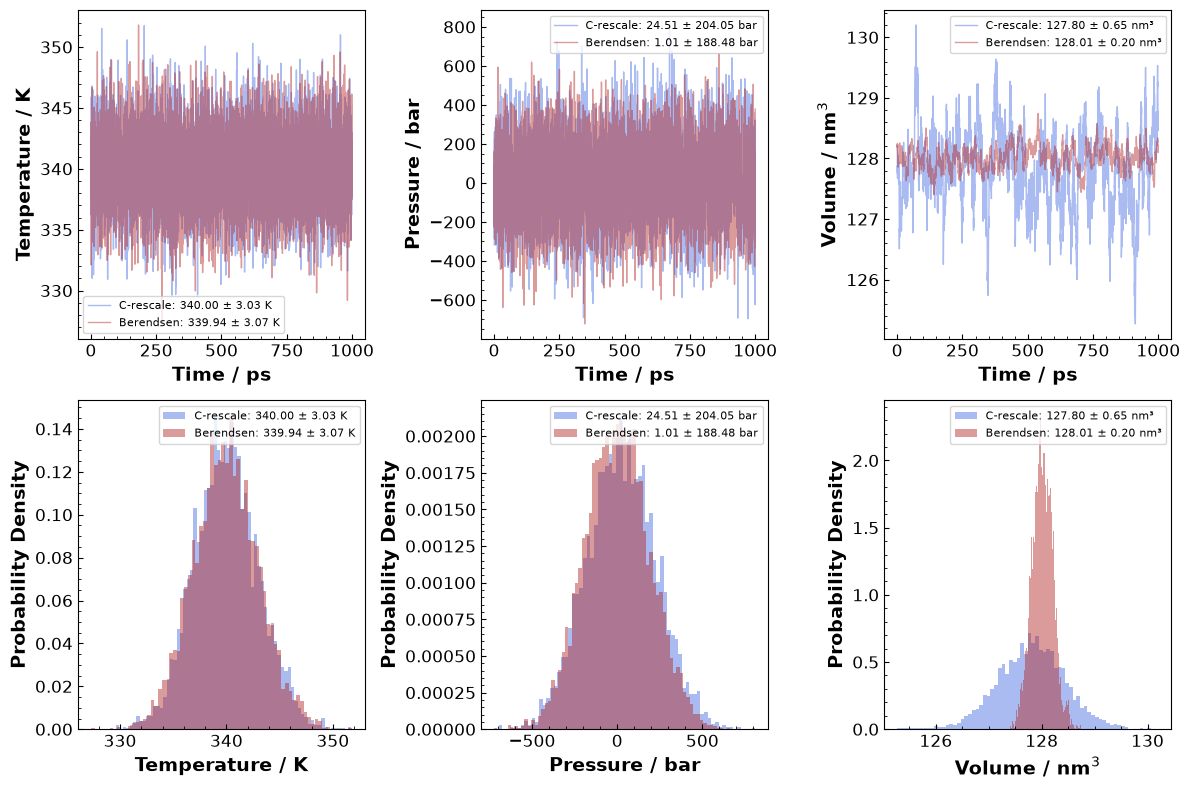

In [13]:
npt_crescale = np.loadtxt('exercise-2/results/npt_crescale_energy.xvg', comments=('#', '@'))
npt_berendsen = np.loadtxt('exercise-2/results/npt_berendsen_energy.xvg', comments=('#', '@'))

colors = {
    "C-rescale":"royalblue",
    "Berendsen":"firebrick"
}

fig, ax = plt.subplots(2, 3, figsize=(12, 8), layout='tight')
for name, data in [('C-rescale', npt_crescale), ('Berendsen', npt_berendsen)]:
    for trace_axis, hist_axis, column, unit in zip(ax[0,:], ax[1,:], (1, 2, 3), ('K', 'bar', 'nm³')):
        values = data[:, column]
        label = f'{name}: {values.mean():.2f} ± {values.std(ddof=1):.2f} {unit}'
        trace_axis.plot(data[:, 0], values, lw=1, label=label, color=colors[name], alpha=0.45)
        hist_axis.hist(values, bins=int(np.sqrt(len(data))), density=True, alpha=0.45,
                       label=label, color=colors[name])
    print(f'{name}: pressure = {data[:, 2].mean():.1f} ± {data[:, 2].std(ddof=1):.1f} bar; '
          f'volume = {data[:, 3].mean():.2f} ± {data[:, 3].std(ddof=1):.2f} nm³ (mean ± SD)')

for axis, ylabel in zip(ax[0,:], ('Temperature / K', 'Pressure / bar', r'Volume / $\mathbf{nm}^3$')):
    axis.set_xlabel(
        "Time / ps",
        fontsize = 14,
        fontweight = "bold"
    )

    axis.set_ylabel(
        ylabel,
        fontsize = 14,
        fontweight = "bold"
    )

    axis.minorticks_on()
    axis.tick_params(
        which = "both",
        direction = "in",
        labelsize = 12
    )

    axis.legend(fontsize=8)

for axis, xlabel in zip(ax[1,:], ('Temperature / K', 'Pressure / bar', r'Volume / $\mathbf{nm}^3$')):
    axis.set_ylabel(
        "Probability Density",
        fontsize = 14,
        fontweight = "bold"
    )

    axis.set_xlabel(
        xlabel,
        fontsize = 14,
        fontweight = "bold"
    )

    axis.minorticks_on()
    axis.tick_params(
        which = "both",
        direction = "in",
        labelsize = 12
    )

    axis.legend(fontsize=8)

The pressure is all over the place in both runs, just as it was in Part 1. For these particular 1 ns trajectories, the average pressures are about 24.5 bar with C-rescale and 1.0 bar with Berendsen; both are subject to fluctuations of around 200 bar. Would we be justified in declaring Berendsen the better barostat because its *average* happens to lie closer to 1 bar here? Look instead at the volume: the averages are both close to 128 $\mathrm{nm}^3$, but the Berendsen trace looks much quieter. 

The distributions in the bottom row make this clearer. For the supplied trajectories the standard deviation of the volume is about 0.65 $\mathrm{nm}^3$ for C-rescale, but only about 0.20 $\mathrm{nm}^3$ for Berendsen. In other words, Berendsen can bring the *average* pressure towards the target while making the box fluctuate much less. That is the problem: in an NPT ensemble we expect fluctuations, not just a plausible mean. Do NOT interpret the histogram as a precise equilibrium distribution, though; 1 ns from a single starting point is still short and neighbouring observations are correlated. We would need longer and preferably independent runs before quantifying the variance reliably.

Can we make that difference more quantitative? For an equilibrium NPT system, the fluctuations in volume are related to its **isothermal compressibility**, $\kappa_T$: how much the volume responds to a change in pressure at fixed temperature. The fluctuation formula is

$$\kappa_T = \frac{\langle V^2 \rangle - \langle V \rangle^2}{k_\mathrm{B} T \langle V \rangle} = \frac{\mathrm{Var}(V)}{k_\mathrm{B} T \langle V \rangle}.$$

Here $k_\mathrm{B}$ is Boltzmann's constant and $T$ is our target temperature of 340 K. We have the volumes in $\mathrm{nm}^3$, so to use $k_\mathrm{B}$ in joules per kelvin we must convert them to $\mathrm{m}^3$ first ($1\;\mathrm{nm}^3 = 10^{-27}\;\mathrm{m}^3$). The result is in inverse pascals; multiply by $10^5$ to express it in $\mathrm{bar}^{-1}$. In both `.mdp` files we supplied `compressibility = 4.5e-5` $\mathrm{bar}^{-1}$. Does the compressibility inferred from each volume trace resemble that value? Let's calculate it.

C-rescale: apparent κ_T = 6.9e-05 bar^-1
Berendsen: apparent κ_T = 6.3e-06 bar^-1


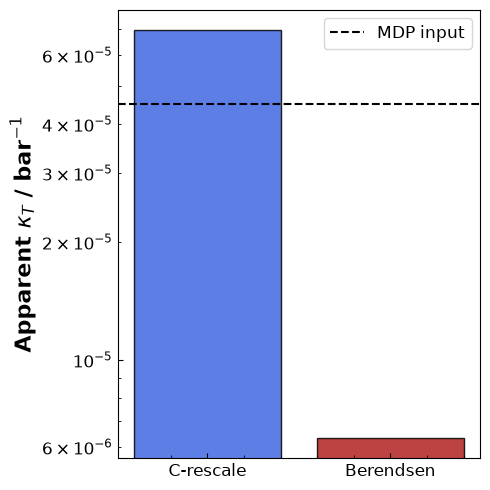

In [14]:
k_B = 1.380649e-23  # J/K
temperature_K = 340
input_compressibility = 4.5e-5  # bar^-1

fig, ax = plt.subplots(figsize=(5, 5), layout='tight')
for name, data in [('C-rescale', npt_crescale), ('Berendsen', npt_berendsen)]:
    volume_m3 = data[:, 3] * 1e-27  # nm^3 -> m^3
    kappa_Pa = np.var(volume_m3, ddof=1) / (k_B * temperature_K * np.mean(volume_m3))
    kappa_bar = kappa_Pa * 1e5  # Pa^-1 -> bar^-1
    ax.bar(name, kappa_bar, color=colors[name], edgecolor = "k", alpha = 0.85)
    print(f'{name}: apparent κ_T = {kappa_bar:.2g} bar^-1')

ax.axhline(input_compressibility, ls='--', color='black', label='MDP input')
ax.set_yscale("log", base = 10)
ax.set_ylabel(r'Apparent $\kappa_T$ / $\mathbf{bar}^{-1}$', fontsize = 16, fontweight = "bold")
ax.minorticks_on()
ax.tick_params(
    which = "both",
    direction = "in",
    labelsize = 12
)
ax.legend(fontsize = 12)

What do you find? From these 1 ns trajectories we obtain roughly $6.9 \times 10^{-5}$ $\mathrm{bar}^{-1}$ with C-rescale, but only $6.3 \times 10^{-6}$ $\mathrm{bar}^{-1}$ with Berendsen! The latter is about seven times smaller than the value we supplied in the `.mdp`, despite its average pressure being closer to 1 bar. For Berendsen this is only an **apparent** compressibility: it does not sample the NPT volume distribution assumed by the formula, so we should NOT interpret it as a thermodynamic property of the system. The C-rescale estimate is also not expected to match the input perfectly after just 1 ns; slow and correlated fluctuations mean we would need longer, preferably independent runs for a reliable number.

What have we learned? Choosing a coupling scheme is not simply a matter of asking whether the mean temperature or pressure matches a reference. We should also ask what our observable is: if we care about *dynamics*, randomising velocities can matter enormously; if we care about the *ensemble*, artificially suppressing box fluctuations matters too. Which plots would you check if you were going to carry on to a longer production simulation?